Decision Tree Accuracy: 0.9583333333333334
Bagging Accuracy: 0.9583333333333334
Cross-validation Accuracy (DT): 0.9916666666666668


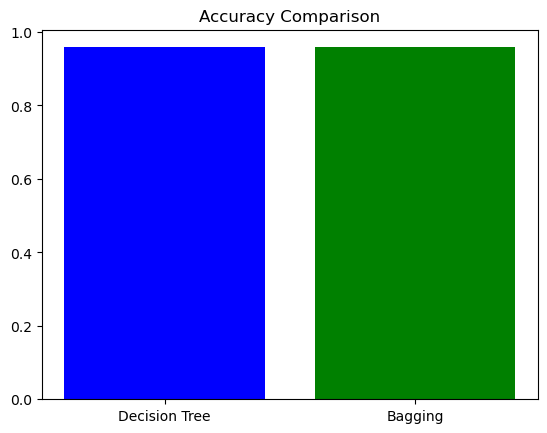

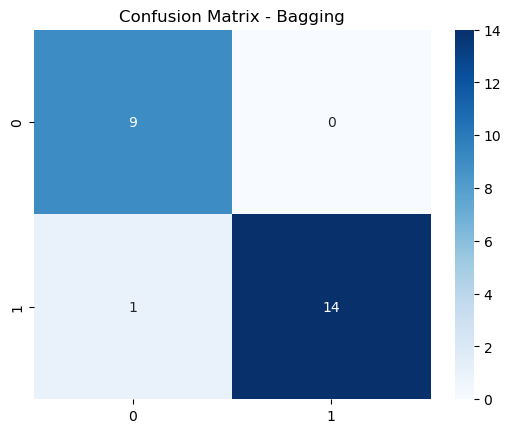

CV Accuracy: 0.9916666666666668


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    random_state=42
)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

cv_score = cross_val_score(dt, X, y, cv=5).mean()
print("Cross-validation Accuracy (DT):", cv_score)

plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag], color=["blue", "green"])
plt.title("Accuracy Comparison")
plt.show()

cm = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Bagging")
plt.show()

scores = cross_val_score(bag, X, y, cv=5)
print("CV Accuracy:", scores.mean())

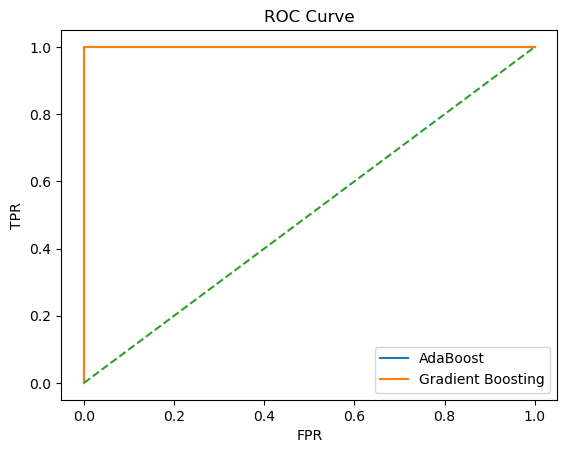

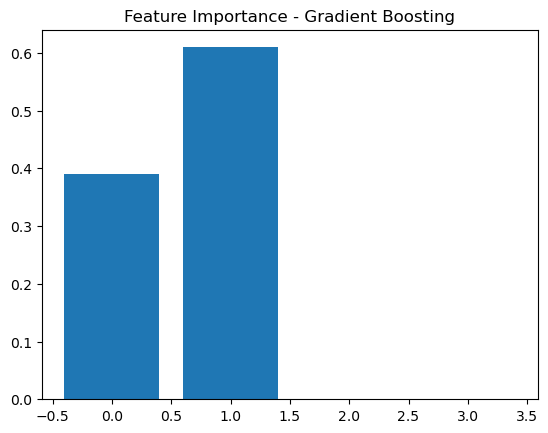

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve

df = pd.read_csv("churn_boosting.csv")

df = df.apply(LabelEncoder().fit_transform)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify =y)

ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)
y_prob_ada = ada.predict_proba(X_test)[:,1]

gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

importances = gb.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

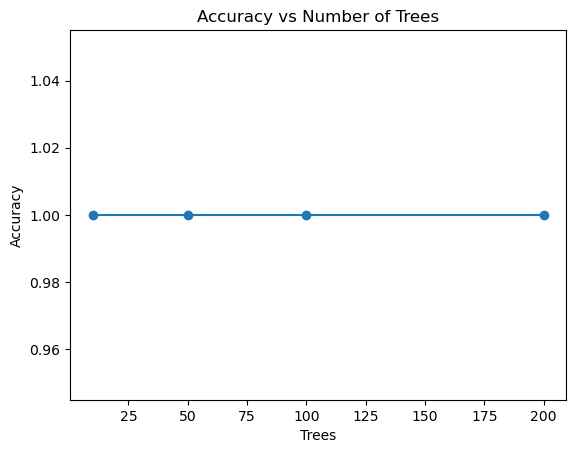

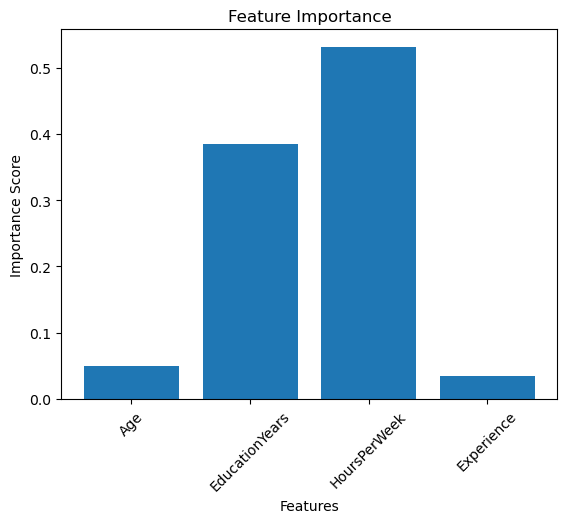

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("income_random_forest.csv")

df = df.apply(LabelEncoder().fit_transform)

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

trees = [10, 50, 100, 200]
accuracies = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(trees, accuracies, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Trees")
plt.ylabel("Accuracy")
plt.show()

rf_final = RandomForestClassifier(n_estimators=100)
rf_final.fit(X_train, y_train)

plt.bar(X.columns, rf_final.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

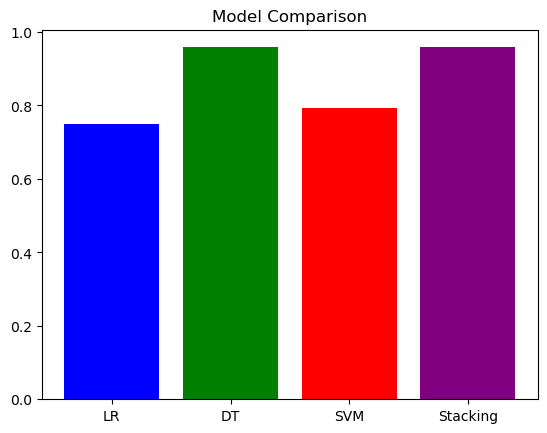

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("heart_stacking.csv")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stack = StackingClassifier(estimators=models, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)

accs = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    accuracy_score(y_test, svm.predict(X_test)),
    accuracy_score(y_test, stack.predict(X_test))
]

labels = ["LR", "DT", "SVM", "Stacking"]
plt.bar(labels, accs, color=['blue','green','red','purple'])
plt.title("Model Comparison")
plt.show()

Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64


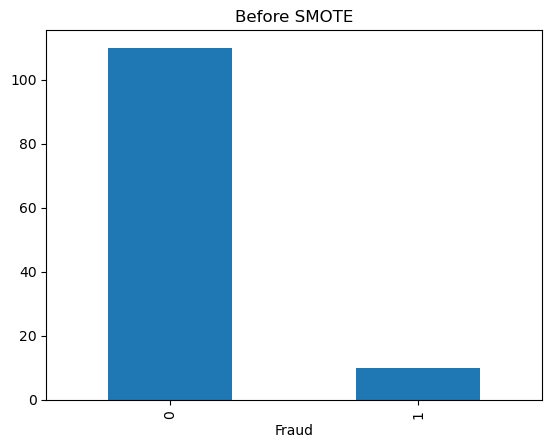

After SMOTE:
 Fraud
0    88
1    88
Name: count, dtype: int64


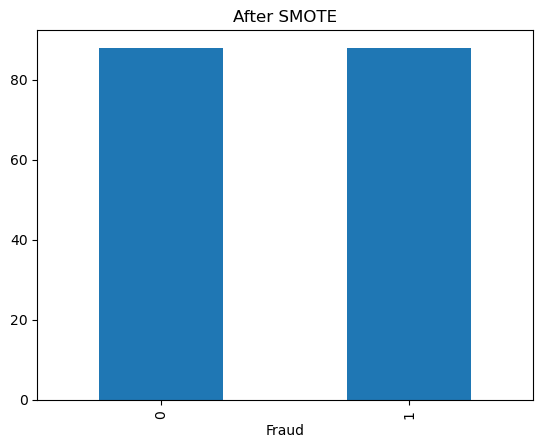

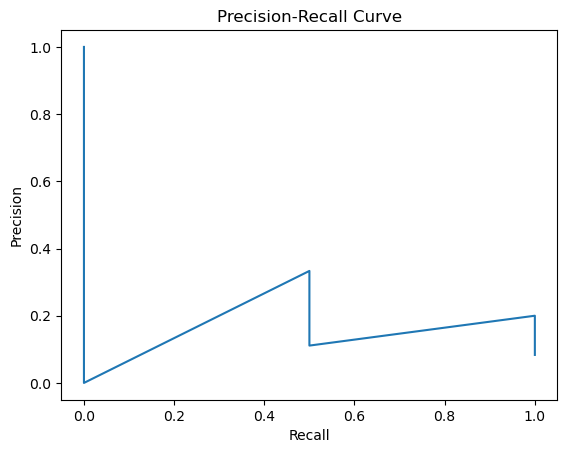

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE

df = pd.read_csv("fraud_smote.csv")

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

print("Before SMOTE:\n", y.value_counts())

y.value_counts().plot(kind='bar', title="Before SMOTE")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

pd.Series(y_res).value_counts().plot(kind='bar', title="After SMOTE")
plt.show()

model_smote = RandomForestClassifier()
model_smote.fit(X_res, y_res)

y_prob = model_smote.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()